# 2D Maze Environment Demo

This notebook demonstrates the 2D Maze environment where you navigate to a target.

In [2]:
import gymnasium as gym
import numpy as np
from IPython.display import display
from PIL import Image

## 1. Create and Inspect Environment (Easy - 9x9)

In [4]:
env = gym.make("maze_2d/easy", seed=42)
print(f"Maze size: {env.unwrapped.maze_height}x{env.unwrapped.maze_width}")
print(f"Action Space: {env.action_space}")
print(f"Available actions: {env.action_space.get_function_names()}")
print(f"Directions: 0=right, 1=up, 2=left, 3=down")

Maze size: 9x9
Action Space: FuncConditional(['move', 'stop'])
Available actions: ['move', 'stop']
Directions: 0=right, 1=up, 2=left, 3=down


## 2. Reset and View Initial State

Observation shape: (225, 225, 3)
Agent location: [1 7]
Target location: [7 1]
Distance: 12.0


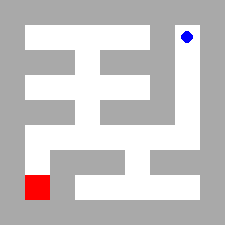


Task Prompt:
You are navigating a 9x9 maze. The maze consists of walls (gray) and paths (white). You are represented by a blue circle, and your goal is to reach the red target square.

Available actions:
1. 'move': Move in one of four directions. Format: `('move', direction)` where direction is an integer:
   - 0=right, 1=up, 2=left, 3=down
2. 'stop': End the navigation session. Format: `('stop', 'stop')`

Success: You succeed if you reach the red target square.

Please respond with exactly one action and its arguments in the specified format. For example:
- To move right: `('move', 0)`
- To move up: `('move', 1)`
- To move left: `('move', 2)`
- To move down: `('move', 3)`
- To stop: `('stop', 'stop')`


In [5]:
obs, info = env.reset()
print(f"Observation shape: {obs.shape}")
print(f"Agent location: {info['agent']}")
print(f"Target location: {info['target']}")
print(f"Distance: {info['distance']}")

display(Image.fromarray(obs))
print(f"\nTask Prompt:\n{env.get_prompt()}")

## 3. Test Manual Actions


Move right: ('move', 0)
Agent: [1 7], Distance: 12.00
Feedback: Cannot move into a wall.


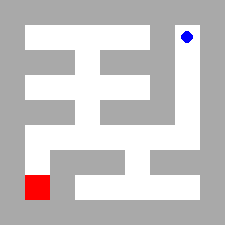


Move up: ('move', 1)
Agent: [1 7], Distance: 12.00
Feedback: Cannot move into a wall.


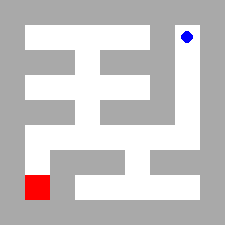


Move left: ('move', 2)
Agent: [1 7], Distance: 12.00
Feedback: Cannot move into a wall.


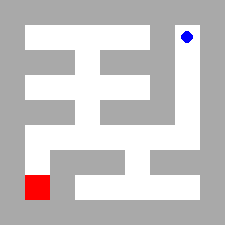


Move down: ('move', 3)
Agent: [2 7], Distance: 11.00
Feedback: Action executed successfully.


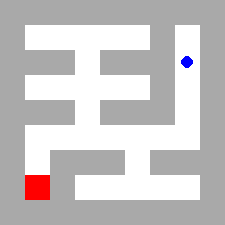

In [6]:
# Try moving in different directions
for direction, name in [(0, 'right'), (1, 'up'), (2, 'left'), (3, 'down')]:
    action = f"('move', {direction})"
    obs, reward, terminated, truncated, info = env.step(action)
    print(f"\nMove {name}: {action}")
    print(f"Agent: {info['agent']}, Distance: {info['distance']:.2f}")
    print(f"Feedback: {info['env_feedback']}")
    display(Image.fromarray(obs))
    if "Cannot" not in info['env_feedback']:
        break  # Stop after first successful move

## 4. Test Solver

Initial - Agent: [1 7], Target: [7 1], Distance: 12


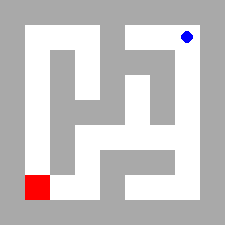


Solver generated 14 actions

Step 1: ('move', 3)
Agent: [2 7], Distance: 11.00


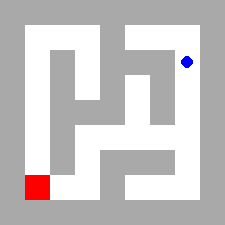


Step 2: ('move', 3)
Agent: [3 7], Distance: 10.00


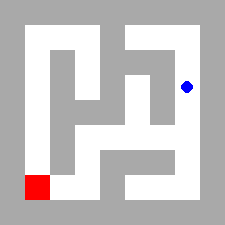


Step 3: ('move', 3)
Agent: [4 7], Distance: 9.00


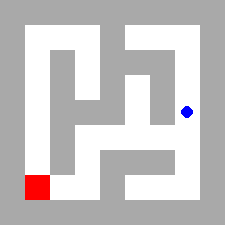


Step 4: ('move', 3)
Agent: [5 7], Distance: 8.00

Step 5: ('move', 2)
Agent: [5 6], Distance: 7.00

Step 6: ('move', 2)
Agent: [5 5], Distance: 6.00

Step 11: ('move', 2)
Agent: [7 2], Distance: 1.00

Step 13: ('stop', 'stop')
Agent: [7 1], Distance: 0.00


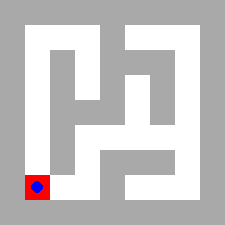


✓ Maze solved! Reward: 1.0


In [7]:
env = gym.make("maze_2d/easy", seed=100)
obs, info = env.reset()
print(f"Initial - Agent: {info['agent']}, Target: {info['target']}, Distance: {info['distance']:.0f}")
display(Image.fromarray(obs))

# Get solver actions
actions = env.solve()
print(f"\nSolver generated {len(actions)} actions")

# Execute solver actions
for i, action in enumerate(actions):
    obs, reward, terminated, truncated, info = env.step(action)
    if i < 5 or i % 5 == 0 or terminated:  # Show first 5, then every 5th, and final
        print(f"\nStep {i+1}: {action}")
        print(f"Agent: {info['agent']}, Distance: {info['distance']:.2f}")
        if i < 3 or terminated:
            display(Image.fromarray(obs))
    if terminated:
        print(f"\n✓ Maze solved! Reward: {reward}")
        break

env.close()

## 5. Test Solver with Padding

In [8]:
env = gym.make("maze_2d/easy", seed=200)
obs, info = env.reset()
print(f"Agent: {info['agent']}, Target: {info['target']}")

# Get solver actions with minimum 15 steps (adds back-and-forth moves)
actions = env.solve(num_steps=15)
print(f"\nSolver generated {len(actions)} actions (requested min 15)")
print(f"First few actions: {actions[:5]}")

for action in actions:
    obs, reward, terminated, truncated, info = env.step(action)
    if terminated:
        print(f"Reward: {reward}")
        break

env.close()

Agent: [7 1], Target: [1 7]

Solver generated 16 actions (requested min 15)
First few actions: ["('move', 0)", "('move', 0)", "('move', 0)", "('move', 2)", "('move', 0)"]
Reward: 1.0


## 6. Test Hard Difficulty (11x11)

Hard difficulty - 11x11 maze
Agent: [1 9], Target: [9 1], Distance: 16


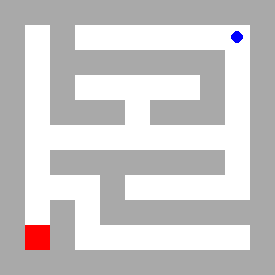


Solution requires 18 steps
Solved! Reward: 1.0


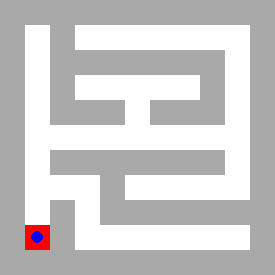

In [10]:
env_hard = gym.make("maze_2d/hard", seed=42)
obs, info = env_hard.reset()
print(f"Hard difficulty - {env_hard.unwrapped.maze_height}x{env_hard.unwrapped.maze_width} maze")
print(f"Agent: {info['agent']}, Target: {info['target']}, Distance: {info['distance']:.0f}")
display(Image.fromarray(obs))

# Solve it
actions = env_hard.solve()
print(f"\nSolution requires {len(actions)} steps")
for action in actions:
    obs, reward, terminated, truncated, info = env_hard.step(action)
    if terminated:
        print(f"Solved! Reward: {reward}")
        display(Image.fromarray(obs))
        break

env_hard.close()